In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

# 1. Đọc dữ liệu giá tiền (để tính trọng số)
df_prices = pd.read_csv("../data/processed/cleaned_uk_data.csv")

# Tính giá trung bình cho từng 
# sản phẩm (vì giá có thể thay đổi theo thời điểm)
product_prices = df_prices.groupby('Description')['UnitPrice'].mean().to_dict()

print("Đã tải xong bảng giá sản phẩm!")
print(f"Ví dụ giá 'POSTAGE': {product_prices.get('POSTAGE', 0):.2f} bảng")

Đã tải xong bảng giá sản phẩm!
Ví dụ giá 'POSTAGE': 168.08 bảng


C:\Users\admin\AppData\Local\Temp\ipykernel_21928\2125762526.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_prices = pd.read_csv("../data/processed/cleaned_uk_data.csv")


In [2]:
# 2. Đọc file luật FP-Growth đã chạy xong
rules = pd.read_csv("../data/processed/rules_fpgrowth_filtered.csv")

# Hàm tính tổng giá trị của một combo sản phẩm
def calculate_basket_value(itemset_str):
    # Chuyển chuỗi "{'A', 'B'}" thành list ['A', 'B']
    try:
        # Xử lý chuỗi frozenset hơi phức tạp chút
        items = itemset_str.replace("frozenset({", "").replace("})", "").replace("'", "").split(", ")
        total_price = sum([product_prices.get(item, 0) for item in items])
        return total_price
    except:
        return 0

# Tính giá trị cho vế trái (Antecedents) và vế phải (Consequents)
rules['antecedent_value'] = rules['antecedents'].apply(calculate_basket_value)
rules['consequent_value'] = rules['consequents'].apply(calculate_basket_value)

# TÍNH CHỈ SỐ QUAN TRỌNG: WEIGHTED LIFT (Lift * Giá trị đơn hàng)
# Ý nghĩa: Luật này vừa có sức hút mạnh (Lift cao), vừa bán đồ đắt tiền.
rules['economic_value'] = rules['lift'] * (rules['antecedent_value'] + rules['consequent_value'])

print("Đã tính xong trọng số kinh tế (Economic Value)!")
rules[['antecedents_str', 'consequents_str', 'lift', 'economic_value']].head()

Đã tính xong trọng số kinh tế (Economic Value)!


,antecedents_str,consequents_str,lift,economic_value
0,"HERB MARKER PARSLEY, HERB MARKER ROSEMARY",HERB MARKER THYME,74.567045,191.081915
1,"HERB MARKER MINT, HERB MARKER THYME",HERB MARKER ROSEMARY,74.502403,190.083954
2,"HERB MARKER MINT, HERB MARKER THYME",HERB MARKER PARSLEY,74.297105,189.711210
3,"HERB MARKER PARSLEY, HERB MARKER THYME",HERB MARKER ROSEMARY,74.244244,190.254721
4,"HERB MARKER BASIL, HERB MARKER THYME",HERB MARKER ROSEMARY,74.169983,190.862033


In [5]:
# 3. Tìm các luật "Hiếm nhưng Chất" (Niche Rules) - Đã tinh chỉnh
# Cập nhật ngưỡng dựa trên thống kê dữ liệu thực tế
NICHE_VALUE_THRESHOLD = 100.0  # Tăng lên 100 để lọc ra hàng xịn
NICHE_LIFT_THRESHOLD = 8.0     # Tăng Lift để tìm mối quan hệ chặt chẽ

niche_rules = rules[
    (rules['support'] < 0.03) & 
    (rules['lift'] > NICHE_LIFT_THRESHOLD) & 
    (rules['economic_value'] > NICHE_VALUE_THRESHOLD)
].sort_values(by='economic_value', ascending=False)

print(f"Tìm thấy {len(niche_rules)} luật Niche CHẤT LƯỢNG CAO (thay vì hàng nghìn luật rác)!")
display(niche_rules[['antecedents_str', 'consequents_str', 'support', 'lift', 'economic_value']].head(10))

Tìm thấy 392 luật Niche CHẤT LƯỢNG CAO (thay vì hàng nghìn luật rác)!


,antecedents_str,consequents_str,support,lift,economic_value
112,"DOTCOM POSTAGE, SKULL SHOULDER BAG",SUKI SHOULDER BAG,0.010599,30.858983,9154.524429
156,"DOTCOM POSTAGE, SUKI SHOULDER BAG",SKULL SHOULDER BAG,0.010599,25.419554,7540.881298
157,"DOTCOM POSTAGE, JAM MAKING SET PRINTED",SUKI SHOULDER BAG,0.011598,25.097213,7440.795235
159,"GREEN REGENCY TEACUP AND SAUCER, SUKI SHOULDE...",DOTCOM POSTAGE,0.010155,24.585083,7336.323719
158,BEADED CRYSTAL HEART PINK ON STICK,DOTCOM POSTAGE,0.011154,24.905945,7296.943249
160,"JAM MAKING SET PRINTED, SUKI SHOULDER BAG",DOTCOM POSTAGE,0.011598,24.584464,7288.775750
161,"GREEN REGENCY TEACUP AND SAUCER, RED TOADSTOOL...",DOTCOM POSTAGE,0.010266,24.216496,7231.864721
164,"RECYCLING BAG RETROSPOT , SUKI SHOULDER BAG",DOTCOM POSTAGE,0.010432,23.182576,6902.512917
165,"JUMBO STORAGE BAG SUKI, RED TOADSTOOL LED NIGH...",DOTCOM POSTAGE,0.010099,22.884927,6808.555084
172,"JUMBO BAG RED RETROSPOT, SUKI SHOULDER BAG",DOTCOM POSTAGE,0.013817,22.780819,6766.560671


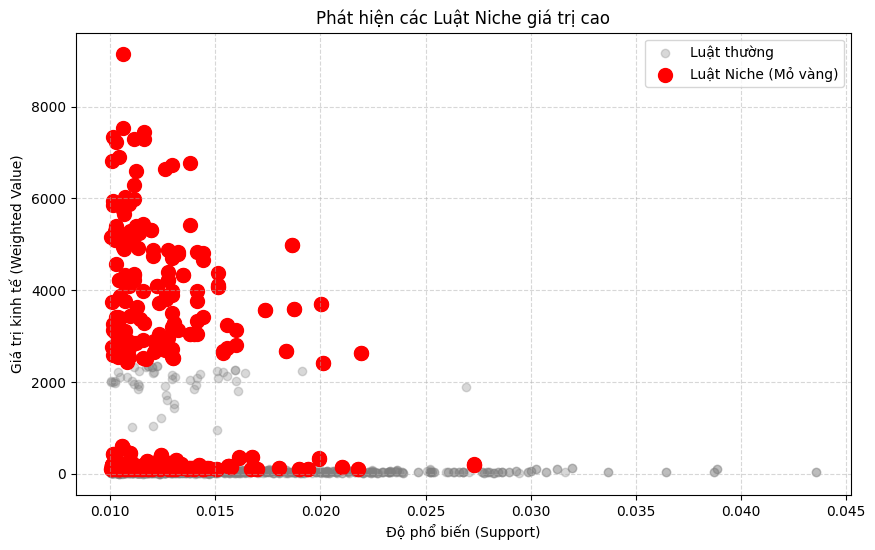

In [6]:
# 4. Vẽ biểu đồ để thầy cô thấy sự khác biệt
plt.figure(figsize=(10, 6))

# Vẽ các luật thường (màu xám, nhỏ)
plt.scatter(rules['support'], rules['economic_value'], alpha=0.3, c='gray', label='Luật thường')

# Vẽ các luật Niche (màu đỏ, to)
plt.scatter(niche_rules['support'], niche_rules['economic_value'], alpha=1.0, c='red', s=100, label='Luật Niche (Mỏ vàng)')

plt.xlabel('Độ phổ biến (Support)')
plt.ylabel('Giá trị kinh tế (Weighted Value)')
plt.title('Phát hiện các Luật Niche giá trị cao')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()